In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

In [3]:
df = pd.read_parquet("../dataset/BGL_Preprocessed.parquet")

print(df.shape)

df.head()

(4710847, 20)


,Label,Timestamp,Date,Node,Time,NodeRepeat,Type,Component,Severity,Message,Message_Length,Clean_Message,Word_Count,Has_Number,Has_Hex,Has_Path,Keyword_Count,Unique_Word_Count,Uppercase_Ratio,Incident_Type
0,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.363779,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,40,instruction cache parity error corrected,5,False,False,False,1,5,0.0,Memory Error
1,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.527847,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,40,instruction cache parity error corrected,5,False,False,False,1,5,0.0,Memory Error
2,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.675872,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,40,instruction cache parity error corrected,5,False,False,False,1,5,0.0,Memory Error
3,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.823719,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,40,instruction cache parity error corrected,5,False,False,False,1,5,0.0,Memory Error
4,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.982731,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,40,instruction cache parity error corrected,5,False,False,False,1,5,0.0,Memory Error


In [4]:
X = df["Clean_Message"]

y = df["Incident_Type"]

print(X.shape)

print(y.shape)

(4710847,)
(4710847,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(len(X_train))

print(len(X_test))

3768677
942170


In [6]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english",
    min_df=3
)

In [7]:
X_train_tfidf = vectorizer.fit_transform(X_train)

print("Train Shape:", X_train_tfidf.shape)

Train Shape: (3768677, 4658)


In [8]:
X_test_tfidf = vectorizer.transform(X_test)

print("Test Shape:", X_test_tfidf.shape)

Test Shape: (942170, 4658)


In [9]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


In [10]:
y_pred = model.predict(X_test_tfidf)

print("Prediction completed.")

Prediction completed.


In [11]:
import joblib

joblib.dump(model, "../trained_models/logistic_regression_model.pkl")
joblib.dump(vectorizer, "../trained_models/tfidf_vectorizer.pkl")

print("✅ Model and vectorizer saved successfully.")

✅ Model and vectorizer saved successfully.


In [12]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9990872135601855


In [13]:
print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

  Application Failure       1.00      1.00      1.00    145105
     Deployment Error       1.00      1.00      1.00     23006
     Hardware Failure       0.99      1.00      1.00     11664
         Memory Error       1.00      1.00      1.00    127496
Network/Communication       0.98      1.00      0.99     14201
                Other       1.00      1.00      1.00    515250
  Power/Thermal Issue       1.00      1.00      1.00       195
  Storage/File System       0.99      1.00      1.00     31570
     System Interrupt       1.00      1.00      1.00     73683

             accuracy                           1.00    942170
            macro avg       1.00      1.00      1.00    942170
         weighted avg       1.00      1.00      1.00    942170



In [14]:
test_logs = [
    "Node card is not fully functional",
    "ciod: Error loading program image, Exec format error",
    "instruction cache parity error corrected",
    "idoproxydb hit ASSERT condition in transport manager",
    "machine check interrupt detected",
    "lustre mount failed no such file or directory",
    "packet transport connection failed",
    "temperature voltage rail clock error detected"
]

test_clean = [text.lower() for text in test_logs]

test_vectors = vectorizer.transform(test_clean)
predictions = model.predict(test_vectors)
probabilities = model.predict_proba(test_vectors)

for log, pred, prob in zip(test_logs, predictions, probabilities):
    confidence = prob.max() * 100
    print(f"LOG: {log}")
    print(f"PREDICTED INCIDENT: {pred}")
    print(f"CONFIDENCE: {confidence:.2f}%")
    print("-" * 60)

LOG: Node card is not fully functional
PREDICTED INCIDENT: Hardware Failure
CONFIDENCE: 100.00%
------------------------------------------------------------
LOG: ciod: Error loading program image, Exec format error
PREDICTED INCIDENT: Deployment Error
CONFIDENCE: 100.00%
------------------------------------------------------------
LOG: instruction cache parity error corrected
PREDICTED INCIDENT: Memory Error
CONFIDENCE: 100.00%
------------------------------------------------------------
LOG: idoproxydb hit ASSERT condition in transport manager
PREDICTED INCIDENT: Application Failure
CONFIDENCE: 97.78%
------------------------------------------------------------
LOG: machine check interrupt detected
PREDICTED INCIDENT: System Interrupt
CONFIDENCE: 99.98%
------------------------------------------------------------
LOG: lustre mount failed no such file or directory
PREDICTED INCIDENT: Storage/File System
CONFIDENCE: 100.00%
------------------------------------------------------------
LO

In [15]:
hard_test_logs = [
    "parity fault detected in instruction cache",
    "application terminated unexpectedly after assertion failure",
    "node board diagnostics failed during startup",
    "binary could not be executed due to invalid format",
    "communication stream lost while sending message",
    "file access denied during mount operation"
]

hard_clean = [text.lower() for text in hard_test_logs]

hard_vectors = vectorizer.transform(hard_clean)
hard_predictions = model.predict(hard_vectors)
hard_probabilities = model.predict_proba(hard_vectors)

for log, pred, prob in zip(hard_test_logs, hard_predictions, hard_probabilities):
    print(f"LOG: {log}")
    print(f"PREDICTED INCIDENT: {pred}")
    print(f"CONFIDENCE: {prob.max()*100:.2f}%")
    print("-" * 60)

LOG: parity fault detected in instruction cache
PREDICTED INCIDENT: Memory Error
CONFIDENCE: 99.89%
------------------------------------------------------------
LOG: application terminated unexpectedly after assertion failure
PREDICTED INCIDENT: Other
CONFIDENCE: 56.84%
------------------------------------------------------------
LOG: node board diagnostics failed during startup
PREDICTED INCIDENT: Storage/File System
CONFIDENCE: 67.46%
------------------------------------------------------------
LOG: binary could not be executed due to invalid format
PREDICTED INCIDENT: Other
CONFIDENCE: 72.72%
------------------------------------------------------------
LOG: communication stream lost while sending message
PREDICTED INCIDENT: Other
CONFIDENCE: 70.24%
------------------------------------------------------------
LOG: file access denied during mount operation
PREDICTED INCIDENT: Storage/File System
CONFIDENCE: 72.44%
------------------------------------------------------------


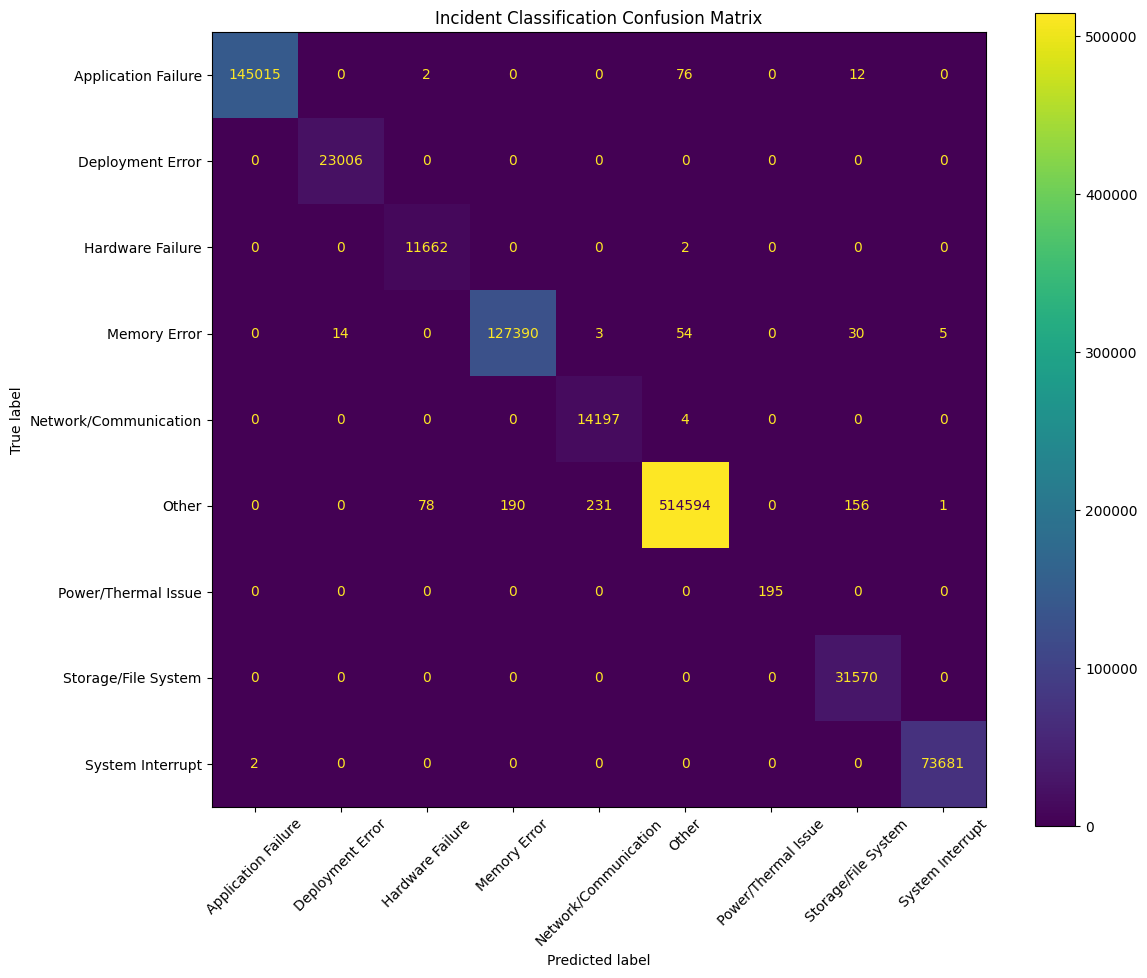

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = model.classes_

cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Incident Classification Confusion Matrix")
plt.tight_layout()
plt.show()

In [17]:
import re

def clean_log(text):
    text = str(text).lower()

    text = re.sub(r'\([^)]*\)', ' ', text)
    text = re.sub(r'0x[a-fA-F0-9]+', ' ', text)
    text = re.sub(r'[/\\][^\s]+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [20]:
def predict_log(log_text):
    clean_text = clean_log(log_text)

    vector = vectorizer.transform([clean_text])

    prediction = model.predict(vector)[0]
    probabilities = model.predict_proba(vector)[0]

    confidence = probabilities.max() * 100

    result = {
        "original_log": log_text,
        "clean_log": clean_text,
        "predicted_incident": prediction,
        "confidence": float(round(confidence, 2))
    }

    return result

In [21]:
sample_log = "instruction cache parity error corrected"

result = predict_log(sample_log)

result

{'original_log': 'instruction cache parity error corrected',
 'clean_log': 'instruction cache parity error corrected',
 'predicted_incident': 'Memory Error',
 'confidence': 100.0}

In [22]:
def get_top_keywords(log_text, top_n=5):
    clean_text = clean_log(log_text)
    vector = vectorizer.transform([clean_text])

    prediction = model.predict(vector)[0]
    class_index = list(model.classes_).index(prediction)

    feature_names = vectorizer.get_feature_names_out()

    tfidf_scores = vector.toarray()[0]
    class_weights = model.coef_[class_index]

    contribution_scores = tfidf_scores * class_weights

    top_indices = contribution_scores.argsort()[-top_n:][::-1]

    keywords = [
        feature_names[i]
        for i in top_indices
        if contribution_scores[i] > 0
    ]

    return keywords

In [23]:
sample_log = "instruction cache parity error corrected"

keywords = get_top_keywords(sample_log)

keywords

['instruction', 'corrected', 'cache', 'parity', 'parity error']

In [24]:
def explain_prediction(log_text):

    result = predict_log(log_text)

    keywords = get_top_keywords(log_text)

    print("=" * 50)
    print("AI LOG ANALYZER")
    print("=" * 50)

    print("\nLOG")
    print("-" * 50)
    print(result["original_log"])

    print("\nINCIDENT")
    print("-" * 50)
    print(result["predicted_incident"])

    print("\nCONFIDENCE")
    print("-" * 50)
    print(f'{result["confidence"]:.2f}%')

    print("\nTOP KEYWORDS")
    print("-" * 50)

    for word in keywords:
        print("•", word)

    print("=" * 50)

In [25]:
explain_prediction(
    "instruction cache parity error corrected"
)

AI LOG ANALYZER

LOG
--------------------------------------------------
instruction cache parity error corrected

INCIDENT
--------------------------------------------------
Memory Error

CONFIDENCE
--------------------------------------------------
100.00%

TOP KEYWORDS
--------------------------------------------------
• instruction
• corrected
• cache
• parity
• parity error
